## Machine Learning 2 Assignment 1.

## Exploratory Data Analysis




In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFECV
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

# Load the dataset
df = pd.read_csv('data.csv')
print('Dataset Loaded Successfully.')
df.head()

Dataset Loaded Successfully.


,MATS3v,nHBint10,MATS3s,MATS3p,nHBDon_Lipinski,minHBint8,MATS3e,MATS3c,minHBint2,MATS3m,...,WTPT-4,WTPT-5,ETA_EtaP_L,ETA_EtaP_F,ETA_EtaP_B,nT5Ring,SHdNH,ETA_dEpsilon_C,MDEO-22,Class
0,0.0908,0,0.0075,0.0173,0,0.0,-0.0436,0.0409,0.0,0.1368,...,0.0000,0.0000,0.1780,1.5488,0.0088,0,0.0,-0.0868,0.00,NonToxic
1,0.0213,0,0.1144,-0.0410,0,0.0,0.1231,-0.0316,0.0,0.1318,...,8.8660,19.3525,0.1739,1.3718,0.0048,2,0.0,-0.0810,0.25,NonToxic
2,0.0018,0,-0.0156,-0.0765,2,0.0,-0.1138,-0.1791,0.0,0.0615,...,5.2267,27.8796,0.1688,1.4395,0.0116,2,0.0,-0.1004,0.00,NonToxic
3,-0.0251,0,-0.0064,-0.0894,3,0.0,-0.0747,-0.1151,0.0,0.0361,...,7.7896,24.7336,0.1702,1.4654,0.0133,2,0.0,-0.1010,0.00,NonToxic
4,0.0135,0,0.0424,-0.0353,0,0.0,-0.0638,0.0307,0.0,0.0306,...,12.3240,19.7486,0.1789,1.4495,0.0120,2,0.0,-0.1071,0.00,NonToxic


No missing values found in the dataset.


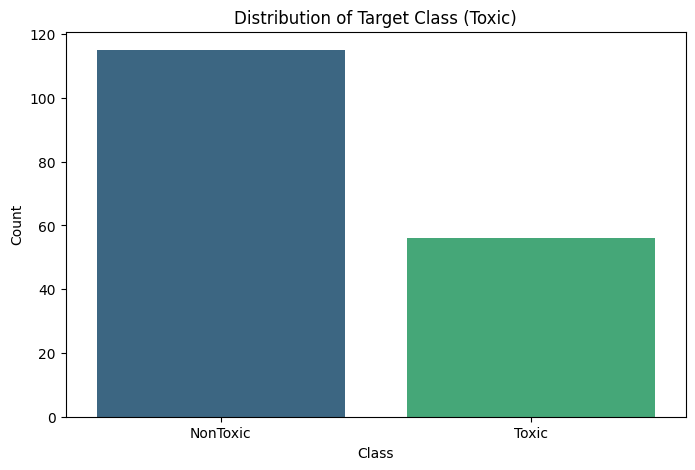

Class Distribution Counts:
Class
NonToxic    115
Toxic        56
Name: count, dtype: int64

Summary Statistics


,MATS3v,nHBint10,MATS3s,MATS3p,nHBDon_Lipinski
count,171.000000,171.000000,171.000000,171.000000,171.000000
mean,-0.031244,0.315789,-0.001001,-0.061501,0.994152
std,0.063559,0.762918,0.063928,0.072891,1.108773
min,-0.311500,0.000000,-0.184600,-0.348500,0.000000
25%,-0.066700,0.000000,-0.036000,-0.099550,0.000000
50%,-0.032500,0.000000,-0.002000,-0.059400,1.000000
75%,0.004850,0.000000,0.029000,-0.017100,2.000000
max,0.141100,4.000000,0.218100,0.129000,6.000000


In [24]:
# Visualization of Missing Values
missing_values = df.isnull().sum()
columns_with_missing = missing_values[missing_values > 0]

if not columns_with_missing.empty:
    plt.figure(figsize=(10, 6))
    sns.barplot(x=columns_with_missing.index, y=columns_with_missing.values)
    plt.title('Missing Values per Column')
    plt.xticks(rotation=45)
    plt.ylabel('Count')
    plt.show()
else:
    print("No missing values found in the dataset.")

# Class Distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Class', hue='Class', palette='viridis', legend=False)
plt.title('Distribution of Target Class (Toxic)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

# Display counts
print("Class Distribution Counts:")
print(df['Class'].value_counts())

# Summary Statistics for Numerical Features
print("\nSummary Statistics")
display(df.select_dtypes(include=['number']).iloc[:, :5].describe())

## Data Preprocessing




In [25]:
le = LabelEncoder()
y = le.fit_transform(df['Class'])
X = df.drop(columns=['Class'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print('Preprocessing Complete: Features scaled and target encoded.')
print(f'Target mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}')

Preprocessing Complete: Features scaled and target encoded.
Target mapping: {'NonToxic': np.int64(0), 'Toxic': np.int64(1)}


## Feature Selection with Cross-Validation




In [26]:
rf_selector = RandomForestClassifier(random_state=42, n_jobs=-1)
selector = RFECV(estimator=rf_selector, step=10, cv=5, scoring='accuracy')

selector.fit(X_scaled_df, y)

print(f'Optimal number of features: {selector.n_features_}')
X_selected = X_scaled_df.iloc[:, selector.support_]

Optimal number of features: 1143


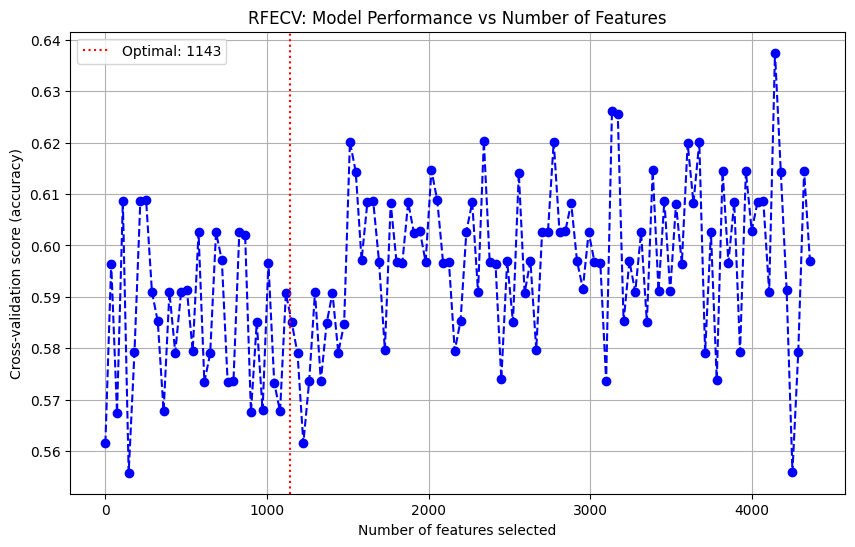

In [14]:


# Visualization of the number of features VS cross-validation scores
plt.figure(figsize=(10, 6))
plt.xlabel("Number of features selected")
plt.ylabel("Cross-validation score (accuracy)")
plt.title("RFECV: Model Performance vs Number of Features")

step = 36
n_features = range(1, len(selector.cv_results_['mean_test_score']) * step + 1, step)

plt.plot(n_features, selector.cv_results_['mean_test_score'], marker='o', linestyle='--', color='b')
plt.axvline(x=selector.n_features_, color='r', linestyle=':', label=f'Optimal: {selector.n_features_}')
plt.legend()
plt.grid(True)
plt.show()

In [17]:
# Model Training and Evaluation
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42, stratify=y)

final_model = RandomForestClassifier(random_state=42, n_jobs=-1)
final_model.fit(X_train, y_train)
y_pred = final_model.predict(X_test)
y_probs = final_model.predict_proba(X_test)[:, 1]

# Metrics Evaluation
print(classification_report(y_test, y_pred, target_names=le.classes_))

metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'ROC-AUC': roc_auc_score(y_test, y_probs),
    'F1-Score (Toxic)': f1_score(y_test, y_pred)
}
display(pd.DataFrame([metrics]))

              precision    recall  f1-score   support

    NonToxic       0.70      0.96      0.81        24
       Toxic       0.50      0.09      0.15        11

    accuracy                           0.69        35
   macro avg       0.60      0.52      0.48        35
weighted avg       0.64      0.69      0.60        35



,Accuracy,ROC-AUC,F1-Score (Toxic)
0,0.685714,0.602273,0.153846
